## 11.10节练习参考答案

## 环境准备

In [ ]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import math

from src.utils import *

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)。

### 练习11.10.1
调节学习率，观察并分析实验结果。

**解答：**

loss: 0.247, 0.012 sec/epoch


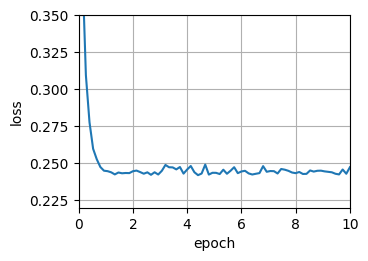

In [2]:
def init_adam_states(feature_dim):
    v_w, v_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    s_w, s_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    return ((v_w, s_w), (v_b, s_b))

def adam(params, states, hyperparams):
    beta1, beta2, eps = 0.9, 0.999, 1e-6
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = beta2 * s + (1 - beta2) * torch.square(p.grad)
            v_bias_corr = v / (1 - beta1 ** hyperparams['t'])
            s_bias_corr = s / (1 - beta2 ** hyperparams['t'])
            p[:] -= hyperparams['lr'] * v_bias_corr / (torch.sqrt(s_bias_corr)
                                                       + eps)
        p.grad.data.zero_()
    hyperparams['t'] += 1

data_iter, feature_dim = get_data_ch11(batch_size=10)
train_ch11(adam, init_adam_states(feature_dim),
               {'lr': 0.01, 't': 1}, data_iter, feature_dim, num_epochs=10);

loss: 0.254, 0.012 sec/epoch


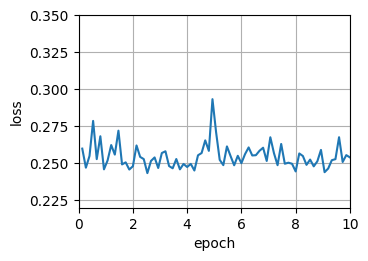

In [3]:
train_ch11(adam, init_adam_states(feature_dim),
               {'lr': 0.05, 't': 1}, data_iter, feature_dim, num_epochs=10);

loss: 0.268, 0.012 sec/epoch


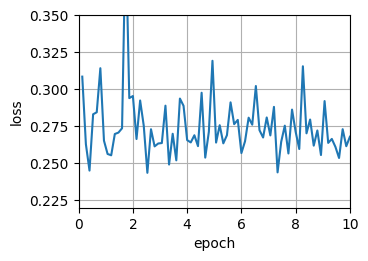

In [4]:
train_ch11(adam, init_adam_states(feature_dim),
               {'lr': 0.1, 't': 1}, data_iter, feature_dim, num_epochs=10);

### 练习11.10.2
试着重写动量和二次矩更新，从而使其不需要偏差校正。

**解答：**

In [5]:
def init_adam_states_update(feature_dim):
    v_w, v_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    s_w, s_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    return ((v_w, s_w), (v_b, s_b))

def adam_update(params, states, hyperparams):
    beta1, beta2, eps = 0.9, 0.999, 1e-6
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = beta2 * s + (1 - beta2) * torch.square(p.grad)
            # 不做偏差校正，直接用 v、s
            p[:] -= hyperparams['lr'] * v / (torch.sqrt(s) + eps)
        p.grad.data.zero_()

loss: 0.248, 0.011 sec/epoch


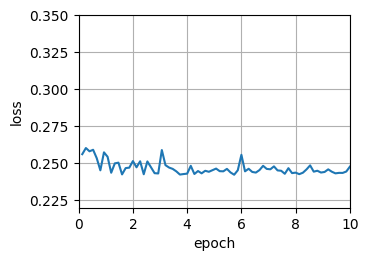

In [6]:
train_ch11(adam_update, init_adam_states(feature_dim),
               {'lr': 0.01, 't': 1}, data_iter, feature_dim, num_epochs=10);

loss: 0.253, 0.011 sec/epoch


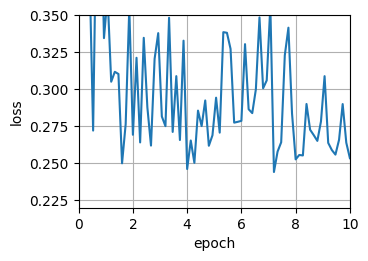

In [7]:
train_ch11(adam_update, init_adam_states(feature_dim),
               {'lr': 0.1, 't': 1}, data_iter, feature_dim, num_epochs=10);

### 练习11.10.3
收敛时为什么需要降低学习率$\eta$？

**解答：**

在Adam算法中，有两个关键的超参数：学习率$\eta$和指数衰减率$\beta_1$、$\beta_2$。

当Adam算法收敛时，降低学习率$\eta$的原因如下：

1. **动量的影响**：Adam算法利用动量来加速梯度下降过程，动量可以帮助算法跳出局部极小值并加速在平坦区域的移动。然而，在接近收敛时，我们希望算法逐渐减缓速度，以避免在极小值附近来回震荡。

2. **过大的学习率会导致震荡**：如果学习率$\eta$过大，那么在收敛阶段，更新步长可能会过大，使得算法在极小值附近来回震荡，而无法稳定地收敛。

3. **稳定性和精度**：当接近最优解时，我们希望算法收敛得更加精确和稳定。通过降低学习率，我们可以确保算法在接近最优解时，以更小的步长进行微调，从而更加精确地找到最优解。

4. **避免“振荡”**：在接近最优解时，如果学习率$\eta$过大，可能会导致优化过程在最优解附近来回震荡，而无法稳定地收敛。通过降低学习率，可以减缓更新的速度，避免这种振荡现象。

所以，当Adam算法接近收敛时，逐步降低学习率$\eta$是为了保证优化过程的稳定性和精确性，避免在最优解附近震荡，并最终找到一个满足要求的最优解。

### 练习11.10.4
尝试构造一个使用Adam算法会发散而Yogi会收敛的例子。

**解答：**

In [8]:
def init_adam_states(feature_dim):
    v_w, v_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    s_w, s_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    return ((v_w, s_w), (v_b, s_b))

def adam(params, states, hyperparams):
    beta1, beta2, eps = 0.9, 0.999, 1e-6
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = beta2 * s + (1 - beta2) * torch.square(p.grad)
            v_bias_corr = v / (1 - beta1 ** hyperparams['t'])
            s_bias_corr = s / (1 - beta2 ** hyperparams['t'])
            p[:] -= hyperparams['lr'] * v_bias_corr / (torch.sqrt(s_bias_corr)+ eps)
        p.grad.data.zero_()
    hyperparams['t'] += 1

In [9]:
def yogi(params, states, hyperparams):
    beta1, beta2, eps = 0.9, 0.999, 1e-6 #yogi的eps调小
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = s + (1 - beta2) * torch.sign(
                torch.square(p.grad) - s) * torch.square(p.grad)
            v_bias_corr = v / (1 - beta1 ** hyperparams['t'])
            s_bias_corr = s / (1 - beta2 ** hyperparams['t'])
            p[:] -= hyperparams['lr'] * v_bias_corr / (torch.sqrt(s_bias_corr)+ eps)
        p.grad.data.zero_()
    hyperparams['t'] += 1

loss: 0.243, 0.012 sec/epoch


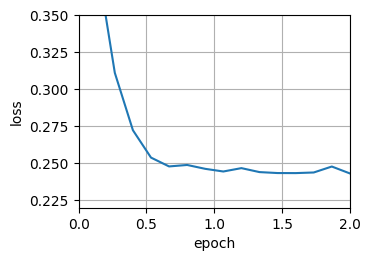

In [10]:
data_iter, feature_dim = get_data_ch11(batch_size=10)
train_ch11(adam, init_adam_states(feature_dim), {'lr': 0.01, 't': 1}, data_iter, feature_dim);

loss: 0.243, 0.012 sec/epoch


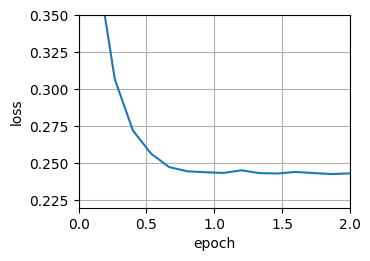

In [11]:
data_iter, feature_dim = get_data_ch11(batch_size=10)
train_ch11(yogi, init_adam_states(feature_dim),
               {'lr': 0.01, 't': 1}, data_iter, feature_dim);